## 1. Overview

This notebook trains the Bogotá AVM (Automated Valuation Model) on the feature matrix produced by `02_feature_engineering.ipynb`.

The target variable is `price_log = log10(precio)`. Predictions are inverted via `10**y_pred` during evaluation and inference.

Steps:

1. **Load & split** — load `data/model_ready.csv`, re-cast categoricals, define features, train/val/test split
2. **Baseline** — LightGBM with default params + early stopping to establish a reference
3. **Hyperparameter tuning** — Optuna over 100 trials optimizing val RMSE (log10)
4. **Final model** — retrain on train+val with best params, fixed rounds from tuning
5. **Evaluation** — RMSE, MAE (log10) + MAPE, MdAPE on original price scale
6. **Feature importance** — split and gain
7. **Export** — save model artifact to `models/`

In [13]:
import itertools
import pandas as pd
import numpy as np
import lightgbm as lgb
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import joblib
import warnings
import catboost
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 2. Import the dataset result of the feature engineering part and split into 70 20 10

In [68]:
df = pd.read_csv('data/model_ready.csv')

for col in ['h3_r6', 'h3_r7', 'h3_r8', 'barrio_ideca', 'antiguedad']:
    df[col] = df[col].astype('category')

In [69]:
poi_cols  = [c for c in df.columns if c.startswith('poi_')]
dist_cols = [c for c in df.columns if c.startswith('dist_')]

FEATURES = [
    'area_m2_log', 'cuartos', 'banios', 'parqueaderos', 'estrato',
    'bedroom_m2', 'bathroom_bedroom', 'tipo_propiedad', 'antiguedad',
    'h3_r6', 'h3_r7', 'h3_r8', 'barrio_ideca',
    *poi_cols, *dist_cols,
]
TARGET   = 'price_log'
CAT_COLS = ['h3_r6', 'h3_r7', 'h3_r8', 'barrio_ideca', 'antiguedad']

X = df[FEATURES]
y = df[TARGET]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=df['tipo_propiedad']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=X_temp['tipo_propiedad']
)

print(f'Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Features: {len(FEATURES)}')

Train: 37634 | Val: 8064 | Test: 8065
Features: 70


## 3. Baseline Models

Two gradient boosting frameworks are evaluated before hyperparameter tuning:

- LightGBM — conservative default params with early stopping on the val set to establish a reference RMSE. Handles high-cardinality categoricals natively (H3 cells, IDECA sectors) without one-hot encoding.
- CatBoost — lightweight grid search over depth and learning_rate before committing to Optuna. Built-in ordered target encoding avoids leakage on sparse categoricals.

XGBoost is excluded — it requires one-hot encoding for categoricals. With features like h3_r8 (thousands of unique cells) and barrio_ideca (1 200+ sectors), OHE produces an extremely wide, sparse matrix where the curse of dimensionality makes tree splits unreliable and memory cost prohibitive.

In [41]:
# LightGBM Dataset — retains raw data in memory (free_raw_data=False) so LightGBM can access original values during categorical encoding.
# feature_pre_filter=False prevents premature feature elimination on sparse categoricals.
lgb_train = lgb.Dataset(
    X_train, y_train, categorical_feature=CAT_COLS, free_raw_data=False,  params={'feature_pre_filter': False}
)
# reference=lgb_train ensures val uses the same categorical encoding schema as train
lgb_eval = lgb.Dataset(X_val, y_val, categorical_feature=CAT_COLS, reference=lgb_train, free_raw_data=False)

# Grid — combinaciones a explorar antes de Optuna
PARAM_GRID = {
    "boosting_type": ["gbdt", "rf"],   # gradient boosting vs bagging
    "num_leaves":    [31, 63, 85, 127],         # model complexity
    "min_data_in_leaf": [30, 50, 100, 300, 400],  # regularization via min samples per leaf
}

# Fixed params shared across all grid combinations
BASE_PARAMS = {
    "objective":        "regression",
    "metric":           "rmse",
    "learning_rate":    0.05,
    "feature_fraction": 0.9,
    "bagging_fraction": 0.8,
    "bagging_freq":     5,
    "verbose":          -1,
}

best_score = np.inf
best_combo = None
results     = []

for combo in itertools.product(*PARAM_GRID.values()):
    combo_params = dict(zip(PARAM_GRID.keys(), combo))
    
    model = lgb.train(
      params={**BASE_PARAMS, **combo_params},
      train_set=lgb_train,
      num_boost_round=2000,
      valid_sets=lgb_eval,
      callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )
    
    y_pred = model.predict(X_val)
    rmse   = np.sqrt(mean_squared_error(y_val, y_pred))
    results.append({**combo_params, 'rmse': rmse})
    
    if rmse < best_score:
      best_score = rmse
      best_combo = combo_params
      best_model = model

print(f'\nBest combo: {best_combo}')
print(f'Best RMSE:  {best_score:.4f}')


Best combo: {'boosting_type': 'gbdt', 'num_leaves': 127, 'min_data_in_leaf': 30}
Best RMSE:  0.0882


### Baseline Results

Gradient boosting (gbdt) outperforms random forest (rf) across all leaf/regularization combinations. This is expected — boosting learns sequentially, each tree correcting the residuals of the previous one, which makes it better suited for structured tabular data with complex interactions like spatial features and high-cardinality categoricals. Random forest's independent trees and majority vote offer more variance reduction but less bias correction.

In [26]:
cat_features_idx = [X_train.columns.get_loc(c) for c in CAT_COLS]

cb = catboost.CatBoostRegressor(loss_function='RMSE', random_seed=42, verbose=0, cat_features=CAT_COLS)

grid = {
    'depth':         [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg':   [1, 3, 5],
}

gs = cb.grid_search(
    grid,
    X=X_train,
    y=y_train,
    cv=5,
    partition_random_seed=42,
    verbose=False,
)

print(gs['params'])


bestTest = 0.1015858497
bestIteration = 999


bestTest = 0.09165867175
bestIteration = 999


bestTest = 0.09066249918
bestIteration = 996


bestTest = 0.1023745003
bestIteration = 999


bestTest = 0.09262069786
bestIteration = 999


bestTest = 0.09150968502
bestIteration = 999


bestTest = 0.1029945491
bestIteration = 999


bestTest = 0.09301481988
bestIteration = 997


bestTest = 0.09204873249
bestIteration = 995


bestTest = 0.09766972155
bestIteration = 999


bestTest = 0.08932748324
bestIteration = 999


bestTest = 0.08907285171
bestIteration = 994


bestTest = 0.09914112909
bestIteration = 999


bestTest = 0.09052283506
bestIteration = 998


bestTest = 0.09002734292
bestIteration = 999


bestTest = 0.1006236745
bestIteration = 999


bestTest = 0.09132979166
bestIteration = 999


bestTest = 0.09094585358
bestIteration = 999


bestTest = 0.0960098954
bestIteration = 999


bestTest = 0.09062949007
bestIteration = 999


bestTest = 0.09169563718
bestIteration = 999


bestTest = 0.0989

### Baseline Results

Both frameworks perform comparably out of the box — LightGBM grid search (0.0882) edges CatBoost defaults (0.0889) by a small margin. Given the negligible difference and LightGBM's native categorical support with the existing pipeline, LightGBM is selected for Optuna tuning.

## 4. Hyperparameter Tuning — Optuna

100 trials over the key LightGBM hyperparameters. Each trial uses early stopping on the val set to avoid overfitting and reduce trial time. The objective is val RMSE (log10).

In [32]:
def objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'rmse',
        'verbose':           -1,
        'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':      trial.suggest_int('bagging_freq', 1, 7),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }

    model = lgb.train(
        params,
        lgb_train,
        num_boost_round=2000,
        valid_sets=lgb_eval,
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
    )

    y_pred = model.predict(X_val)
    return np.sqrt(mean_squared_error(y_val, y_pred))

In [33]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100, show_progress_bar=True)

print(f'\nBest RMSE (log10): {study.best_value:.4f}')
print(f'Best params:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/100 [00:00<?, ?it/s]


Best RMSE (log10): 0.0858
Best params:
  num_leaves: 210
  learning_rate: 0.021092730204142596
  max_depth: 12
  min_child_samples: 13
  feature_fraction: 0.5557955413165133
  bagging_fraction: 0.9778792550662777
  bagging_freq: 3
  reg_alpha: 0.0036170995435278576
  reg_lambda: 2.175787192179575e-07


## 5. Final Model

The best params from Optuna are used to train a model on the val set to retrieve the optimal number of boosting rounds. The final model is then trained on train+val with that fixed number of rounds — no early stopping, no data leakage from the test set.

In [36]:
best_params = {**study.best_params, 'objective': 'regression', 'metric': 'rmse', 'verbose': -1}

# Step 1 — get best iteration using val set
tuned_val = lgb.train(
    best_params,
    lgb_train,
    num_boost_round=2000,
    valid_sets=[lgb_eval],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)],
)
best_rounds = tuned_val.best_iteration
print(f'Best rounds: {best_rounds}')

# Step 2 — retrain on train+val
X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])
d_trainval = lgb.Dataset(X_trainval, label=y_trainval, categorical_feature=CAT_COLS)

final_model = lgb.train(
    best_params,
    d_trainval,
    num_boost_round=best_rounds,
)

Best rounds: 1178


## 6. Evaluation

The test set is evaluated only once — after the final model is trained. Baseline val metrics are shown for comparison.

In [42]:
def evaluate(model, X, y_true, label=''):
    y_pred = model.predict(X)
    rmse_log = np.sqrt(mean_squared_error(y_true, y_pred))
    mae_log  = mean_absolute_error(y_true, y_pred)

    y_true_orig = 10 ** np.array(y_true)
    y_pred_orig = 10 ** y_pred
    ape   = np.abs((y_true_orig - y_pred_orig) / y_true_orig)
    mape  = ape.mean()    * 100
    mdape = np.median(ape) * 100

    print(f'{label}')
    print(f'  RMSE (log10): {rmse_log:.4f}')
    print(f'  MAE  (log10): {mae_log:.4f}')
    print(f'  MAPE:         {mape:.1f}%')
    print(f'  MdAPE:        {mdape:.1f}%')
    return {'rmse_log': rmse_log, 'mae_log': mae_log, 'mape': mape, 'mdape': mdape}

In [43]:
print('=== Baseline grid search (val) ===')
evaluate(best_model, X_val, y_val, 'Val')

print('\n=== Final model Optuna (test) ===')
final_metrics = evaluate(final_model, X_test, y_test, 'Test')


=== Baseline grid search (val) ===
Val
  RMSE (log10): 0.0882
  MAE  (log10): 0.0610
  MAPE:         14.3%
  MdAPE:        9.8%

=== Final model Optuna (test) ===
Test
  RMSE (log10): 0.0855
  MAE  (log10): 0.0579
  MAPE:         13.5%
  MdAPE:        9.1%



### Results

Optuna recovers ~0.7pp MdAPE over the grid search baseline. The gap between MAPE (13.5%) and MdAPE (9.1%) suggests a long tail of high-error listings — consistent with the data quality issues identified in the EDA (misreported prices, luxury segment outliers).

## 7. Feature Importance

Split importance counts how many times a feature is used for splitting. Gain importance measures the total information gain attributable to a feature — more robust for high-cardinality categoricals.

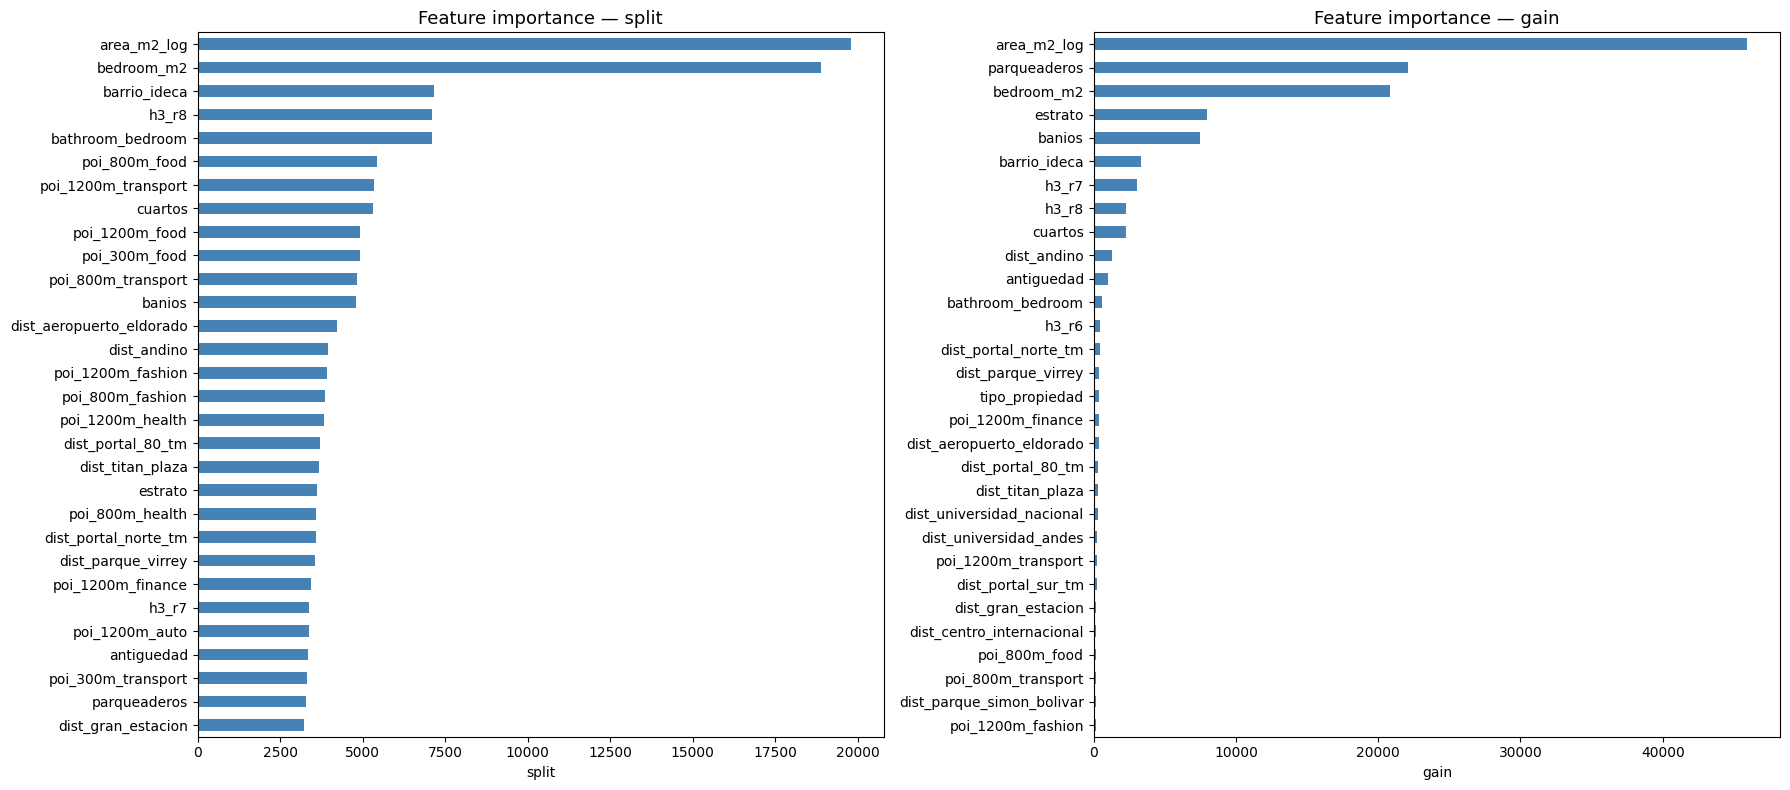

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, importance_type in zip(axes, ['split', 'gain']):
    importance = (
        pd.Series(
            final_model.feature_importance(importance_type=importance_type),
            index=FEATURES,
        )
        .sort_values(ascending=True)
        .tail(30)
    )
    importance.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Feature importance — {importance_type}', fontsize=13)
    ax.set_xlabel(importance_type)

plt.tight_layout()
plt.show()

Area (area_m2_log) dominates both split and gain importance, driven by ultra-high-end properties where size is the primary price differentiator. Spatial categoricals — barrio_ideca and H3 columns — rank next, capturing neighborhood-level price gradients that numeric features cannot encode directly.

POI counts show low gain importance, suggesting that at the current radii (300m–1200m) and with H3 cells already absorbing spatial signal, POI density adds limited marginal information. They may become more relevant with finer radii or in a segment-specific model.

In [75]:
df['predicted_price'] = 10 ** final_model.predict(df[FEATURES])
df['actual_price'] = 10 ** df['price_log']

In [80]:
pd.options.display.float_format = '{:,.0f}'.format
df['ape'] = ((df['actual_price'] - df['predicted_price']).abs() / df['actual_price'] * 100).astype(float)
predicted_df = df[['tipo_propiedad', 'area_m2_log', 'cuartos', 'banios', 'parqueaderos', 'estrato', 'barrio_ideca', 'predicted_price', 'actual_price', 'ape']]

In [93]:
barrios = ['CEDRITOS', 'GUAYMARAL', 'SANTA BARBARA', 'SAN PATRICIO']
df[df['barrio_ideca'].isin(barrios)].groupby('barrio_ideca', observed=True)['ape'].describe()

,count,mean,std,min,25%,50%,75%,max
barrio_ideca,,,,,,,,
CEDRITOS,459,9,10,0,3,7,11,148
GUAYMARAL,76,11,11,0,4,8,13,56
SAN PATRICIO,877,9,8,0,4,7,13,53
SANTA BARBARA,82,9,10,0,3,6,11,60


In [94]:
df.loc[df['barrio_ideca'].isin(barrios), ['barrio_ideca','tipo_propiedad', 'predicted_price', 'actual_price', 'ape']]

,barrio_ideca,tipo_propiedad,predicted_price,actual_price,ape
251,SANTA BARBARA,1,"146,867,680","140,000,000",5
1948,SANTA BARBARA,0,"206,729,798","155,000,000",33
2407,SANTA BARBARA,1,"135,817,237","105,000,000",29
3979,CEDRITOS,0,"202,993,342","178,000,000",14
5251,SANTA BARBARA,1,"127,388,926","135,000,000",6
...,...,...,...,...,...
53602,CEDRITOS,1,"541,815,896","500,000,000",8
53677,SAN PATRICIO,0,"909,329,448","950,000,000",4
53683,SAN PATRICIO,0,"1,105,832,969","1,170,000,000",5
53711,SANTA BARBARA,0,"237,461,779","248,103,000",4


Inference on Full Dataset

The final model predicts prices across all 53,763 listings without leakage — the test set was held out and never used during training or tuning.

Error distribution is healthy across zones:

| Neighborhood  | Listings | Median APE | p75 APE | Max APE |
  |---------------|----------|------------|---------|---------|
  | Cedritos      | 459      | 7%         | 11%     | 148%*   |
  | Guaymaral     | 76       | 8%         | 13%     | 56%     |
  | San Patricio  | 877      | 7%         | 13%     | 53%     |
  | Santa Bárbara | 82       | 6%         | 11%     | 60%     |


*listing 5275 — price inconsistent with zone, model correctly rejects it.

San Patricio performs particularly well given its volume (877 listings) and price range (up to ~1.1B COP). Guaymaral's higher p75 is expected — in the luxury segment a 13% error on a 1B COP property is ~130M COP, a margin that historical transaction data and more listings would help reduce. Next iteration: add historical price context per sector to capture time-based appreciation signals.

## 8. Export

The model is saved in LightGBM text format. The feature list and best params are persisted alongside for reproducibility.

In [96]:
import os, json
os.makedirs('models', exist_ok=True)

final_model.save_model('models/lgbm_bogota_avm_v1.txt')

meta = {
    'features':    FEATURES,
    'cat_cols':    CAT_COLS,
    'target':      TARGET,
    'best_rounds': best_rounds,
    'best_params': best_params,
    'metrics':     final_metrics,
}
with open('models/lgbm_bogota_avm_v1_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved: models/lgbm_bogota_avm_v1.txt')
print('Saved: models/lgbm_bogota_avm_v1_meta.json')

Saved: models/lgbm_bogota_avm_v1.txt
Saved: models/lgbm_bogota_avm_v1_meta.json


Next iteration: train an autoencoder on the listing feature matrix to flag anomalous inputs — unusually low prices for the zone, implausible area/room ratios, or scraper artifacts — before they reach the AVM and inflate APE.